# 3. Asteroid Risk Prediction System - Model Training & Evaluation

**Copyright © 2026 StellarMind - EarthGuard Asteroid Defense AI**  
**All Rights Reserved.**

**Authors**: Gouragopal Mohapatra & Arijit Kumar Mohanty  
**Project**: StellarMind - EarthGuard Asteroid Defense AI  
**Goal**: Train and evaluate Random Forest, Decision Tree, and Regression models

**License**: This code and its contents are proprietary to StellarMind.  
Unauthorized copying, distribution, or use of this material is prohibited without prior written permission.

**Version**: 1.0 | **Date**: April 2026

In [9]:
# 2. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [10]:
# 3. Load preprocessed data
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain columns: {train_df.columns.tolist()[:5]}...")

Train shape: (20695, 74)
Test shape: (5174, 74)

Train columns: ['data_arc_in_days', 'observations_used', 'orbit_uncertainty', 'minimum_orbit_intersection', 'jupiter_tisserand_invariant']...


In [11]:
# 4. Separate features and target
target_col = 'is_potentially_hazardous_asteroid'

# Get all feature columns (exclude target)
feature_cols = [col for col in train_df.columns if col != target_col]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nTarget distribution in train:\n{y_train.value_counts(normalize=True)}")

X_train shape: (20695, 73)
X_test shape: (5174, 73)

Target distribution in train:
is_potentially_hazardous_asteroid
False    0.903407
True     0.096593
Name: proportion, dtype: float64


In [12]:
# 5. Initialize all three models
print("=== INITIALIZING MODELS ===")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
print("✓ Random Forest initialized")

# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
print("✓ Decision Tree initialized")

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
print("✓ Logistic Regression initialized")

=== INITIALIZING MODELS ===
✓ Random Forest initialized
✓ Decision Tree initialized
✓ Logistic Regression initialized


In [13]:
# 6. Train Random Forest
print("=== TRAINING RANDOM FOREST ===")
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"✓ Random Forest training complete")
print(f"  Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {accuracy_score(y_test, rf_pred):.4f}")

=== TRAINING RANDOM FOREST ===
✓ Random Forest training complete
  Training accuracy: 0.9994
  Test accuracy: 0.9981


In [14]:
# 7. Train Decision Tree
print("=== TRAINING DECISION TREE ===")
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print(f"✓ Decision Tree training complete")
print(f"  Training accuracy: {dt_model.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {accuracy_score(y_test, dt_pred):.4f}")

=== TRAINING DECISION TREE ===
✓ Decision Tree training complete
  Training accuracy: 0.9998
  Test accuracy: 0.9977


In [15]:
# 8. Train Logistic Regression
print("=== TRAINING LOGISTIC REGRESSION ===")
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"✓ Logistic Regression training complete")
print(f"  Training accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"  Test accuracy: {accuracy_score(y_test, lr_pred):.4f}")

=== TRAINING LOGISTIC REGRESSION ===
✓ Logistic Regression training complete
  Training accuracy: 0.9466
  Test accuracy: 0.9453


In [16]:
# 9. Calculate all metrics for comparison
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = []
results.append(get_metrics(y_test, rf_pred, 'Random Forest'))
results.append(get_metrics(y_test, dt_pred, 'Decision Tree'))
results.append(get_metrics(y_test, lr_pred, 'Logistic Regression'))

results_df = pd.DataFrame(results)
print("=== MODEL COMPARISON ===")
print(results_df.round(4))

=== MODEL COMPARISON ===
                 Model  Accuracy  Precision  Recall  F1-Score
0        Random Forest    0.9981     0.9900   0.990    0.9900
1        Decision Tree    0.9977     0.9880   0.988    0.9880
2  Logistic Regression    0.9453     0.6441   0.970    0.7741


In [17]:
# 10. Display detailed classification reports
print("=== RANDOM FOREST CLASSIFICATION REPORT ===")
print(classification_report(y_test, rf_pred, target_names=['Non-Hazardous', 'Hazardous']))

print("\n=== DECISION TREE CLASSIFICATION REPORT ===")
print(classification_report(y_test, dt_pred, target_names=['Non-Hazardous', 'Hazardous']))

print("\n=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===")
print(classification_report(y_test, lr_pred, target_names=['Non-Hazardous', 'Hazardous']))

=== RANDOM FOREST CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00      4674
    Hazardous       0.99      0.99      0.99       500

     accuracy                           1.00      5174
    macro avg       0.99      0.99      0.99      5174
 weighted avg       1.00      1.00      1.00      5174


=== DECISION TREE CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      1.00      1.00      4674
    Hazardous       0.99      0.99      0.99       500

     accuracy                           1.00      5174
    macro avg       0.99      0.99      0.99      5174
 weighted avg       1.00      1.00      1.00      5174


=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Non-Hazardous       1.00      0.94      0.97      4674
    Hazardous       0.64      0.97      0.77       500

     accuracy              

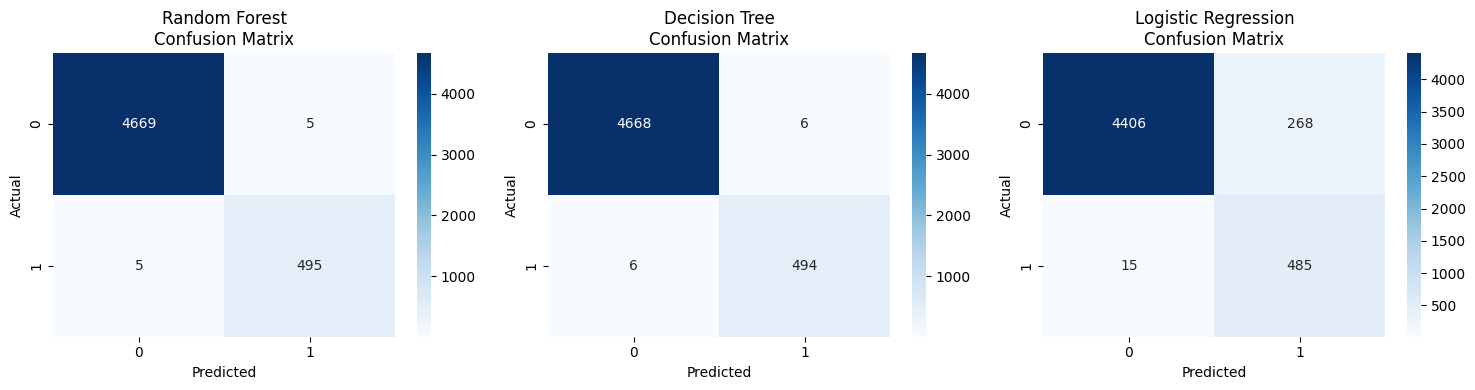

In [18]:
# 11. Confusion matrices visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [('Random Forest', rf_pred), ('Decision Tree', dt_pred), ('Logistic Regression', lr_pred)]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

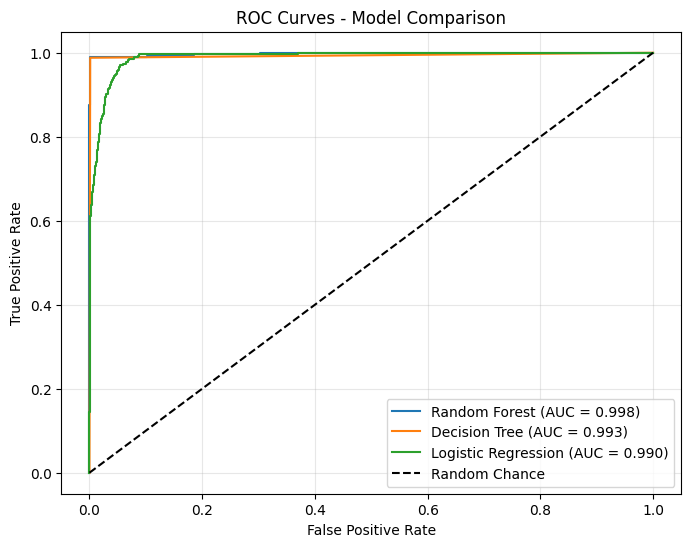

In [19]:
# 12. ROC Curves comparison
plt.figure(figsize=(8, 6))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

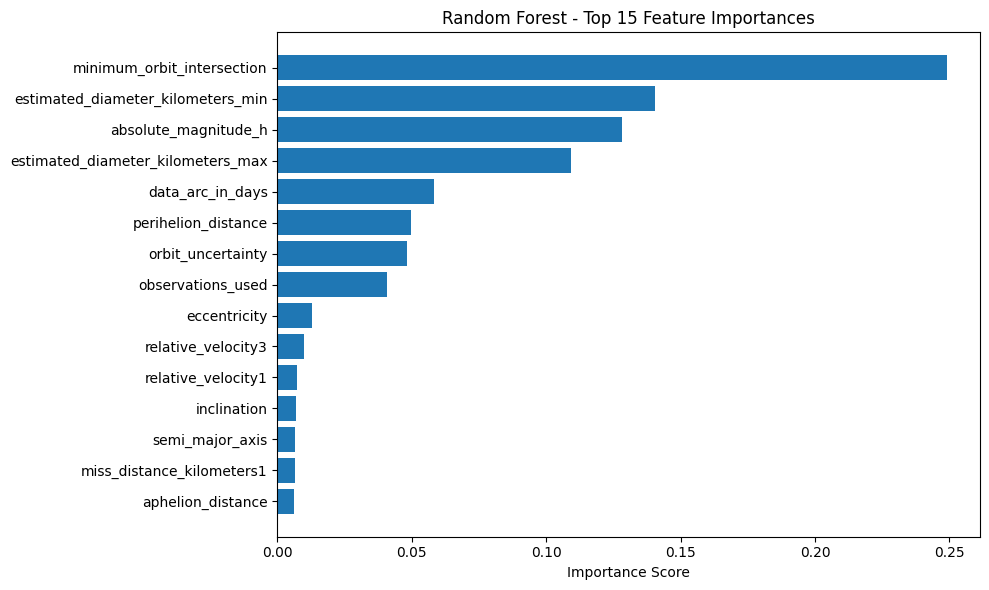

=== TOP 10 IMPORTANT FEATURES ===
                              Feature  Importance
3          minimum_orbit_intersection    0.248918
18  estimated_diameter_kilometers_min    0.140283
17               absolute_magnitude_h    0.128219
19  estimated_diameter_kilometers_max    0.109176
0                    data_arc_in_days    0.058183
11                perihelion_distance    0.049716
2                   orbit_uncertainty    0.048235
1                   observations_used    0.040861
6                        eccentricity    0.012976
27                 relative_velocity3    0.009739


In [20]:
# 13. Feature importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_cols[:30],  # Show top 30 features
    'Importance': rf_model.feature_importances_[:30]
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Importance Score')
plt.title('Random Forest - Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("=== TOP 10 IMPORTANT FEATURES ===")
print(feature_importance.head(10))

In [21]:
# 14. Find best model
best_model_row = results_df.loc[results_df['F1-Score'].idxmax()]
best_model_name = best_model_row['Model']

print("=== BEST MODEL SELECTION ===")
print(f"🏆 Best Model: {best_model_name}")
print(f"   Accuracy:  {best_model_row['Accuracy']:.4f}")
print(f"   Precision: {best_model_row['Precision']:.4f}")
print(f"   Recall:    {best_model_row['Recall']:.4f}")
print(f"   F1-Score:  {best_model_row['F1-Score']:.4f}")

=== BEST MODEL SELECTION ===
🏆 Best Model: Random Forest
   Accuracy:  0.9981
   Precision: 0.9900
   Recall:    0.9900
   F1-Score:  0.9900


In [22]:
# 15. Save models
import joblib

joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(dt_model, '../models/decision_tree.pkl')
joblib.dump(lr_model, '../models/logistic_regression.pkl')

print("✓ All models saved successfully")
print(f"  → Random Forest: ../models/random_forest.pkl")
print(f"  → Decision Tree: ../models/decision_tree.pkl")
print(f"  → Logistic Regression: ../models/logistic_regression.pkl")

✓ All models saved successfully
  → Random Forest: ../models/random_forest.pkl
  → Decision Tree: ../models/decision_tree.pkl
  → Logistic Regression: ../models/logistic_regression.pkl


In [23]:
# 16. Save results to CSV (no images in reports folder)
results_df.to_csv('../reports/model_results.csv', index=False)
print("✓ Model results saved to '../reports/model_results.csv'")
print(results_df.round(4))

✓ Model results saved to '../reports/model_results.csv'
                 Model  Accuracy  Precision  Recall  F1-Score
0        Random Forest    0.9981     0.9900   0.990    0.9900
1        Decision Tree    0.9977     0.9880   0.988    0.9880
2  Logistic Regression    0.9453     0.6441   0.970    0.7741


In [24]:
# 17. Final summary
print("=== MODELING SUMMARY ===")
print(f"Total features used: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"\nModels trained: 3 (Random Forest, Decision Tree, Logistic Regression)")
print(f"Best model: {best_model_name}")
print(f"\n✅ Modeling complete! Ready for evaluation notebook.")

=== MODELING SUMMARY ===
Total features used: 73
Training samples: 20695
Test samples: 5174

Models trained: 3 (Random Forest, Decision Tree, Logistic Regression)
Best model: Random Forest

✅ Modeling complete! Ready for evaluation notebook.


In [25]:
# 18. Quick prediction example
print("=== QUICK PREDICTION EXAMPLE ===")
sample = X_test.iloc[0:1]
actual = y_test.iloc[0]

rf_pred_sample = rf_model.predict(sample)[0]
dt_pred_sample = dt_model.predict(sample)[0]
lr_pred_sample = lr_model.predict(sample)[0]

print(f"Actual: {'Hazardous' if actual == 1 else 'Non-Hazardous'}")
print(f"Random Forest Prediction: {'Hazardous' if rf_pred_sample == 1 else 'Non-Hazardous'}")
print(f"Decision Tree Prediction: {'Hazardous' if dt_pred_sample == 1 else 'Non-Hazardous'}")
print(f"Logistic Regression Prediction: {'Hazardous' if lr_pred_sample == 1 else 'Non-Hazardous'}")

=== QUICK PREDICTION EXAMPLE ===
Actual: Non-Hazardous
Random Forest Prediction: Non-Hazardous
Decision Tree Prediction: Non-Hazardous
Logistic Regression Prediction: Non-Hazardous


---
## Copyright Notice

**© 2026 StellarMind - EarthGuard Asteroid Defense AI. All Rights Reserved.**

This notebook and its contents are the intellectual property of StellarMind.  
No part of this code may be reproduced, distributed, or transmitted in any form without prior written permission from the authors.

**Authors**: Gouragopal Mohapatra & Arijit Kumar Mohanty  
**Project**: Asteroid Risk Prediction System

**Last Updated**: April 2026